# Import the necesary libraries

In [19]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Load the dataset into the notebook

In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yatata1/crack-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/yatata1/crack-dataset


# Set random seeds

In [21]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'Random seed set to : {SEED}')

Random seed set to : 42


In [22]:
import shutil
import random

TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
# test gets the remainder (0.15)

SOURCE_DIRS = {
    "not_cracked": "/kaggle/input/datasets/yatata1/crack-dataset/Concrete/Concrete/Negative/Images",
    "cracked": "/kaggle/input/datasets/yatata1/crack-dataset/Concrete/Concrete/Positive/Images",
}

OUTPUT_DIR = "/kaggle/working/dataset"
IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

random.seed(SEED)

for class_name, src_dir in SOURCE_DIRS.items():
    images = [f for f in Path(src_dir).iterdir() if f.suffix.lower() in IMG_EXTS]
    random.shuffle(images)

    n       = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_valid = int(n * VALID_RATIO)

    splits = {
        "train": images[:n_train],
        "valid": images[n_train:n_train + n_valid],
        "test" : images[n_train + n_valid:],
    }

    print(f"\n── {class_name} ({n} images) ──")
    for split, files in splits.items():
        dest = Path(OUTPUT_DIR) / split / class_name
        dest.mkdir(parents=True, exist_ok=True)
        for f in files:
            shutil.copy2(f, dest / f.name)
        print(f"  {split:>5}: {len(files)} images")


── not_cracked (1183 images) ──
  train: 828 images
  valid: 177 images
   test: 178 images

── cracked (8818 images) ──
  train: 6172 images
  valid: 1322 images
   test: 1324 images


# Set global hyperparameters.

In [23]:
DATASET_DIR = 'dataset'
IMG_SIZE = (224, 224)
BATCH_SIZE = 50
EPOCHS = 20
LR = 1e-3 

# Load the training dataset 

In [24]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/train',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= True,
)

Found 7000 files belonging to 2 classes.


# Load the test dataset

In [25]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/test',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= False
)

Found 1502 files belonging to 2 classes.


# Load the valid dataset

In [26]:
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/valid',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= False
)

Found 1499 files belonging to 2 classes.


# Get class names and number of classes

In [27]:
CLASS_NAMES = test_dataset.class_names
num_classes= len(CLASS_NAMES)
print(f'Classes ({num_classes}): {CLASS_NAMES}')

Classes (2): ['cracked', 'not_cracked']


# Visualise dataset samples

In [28]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

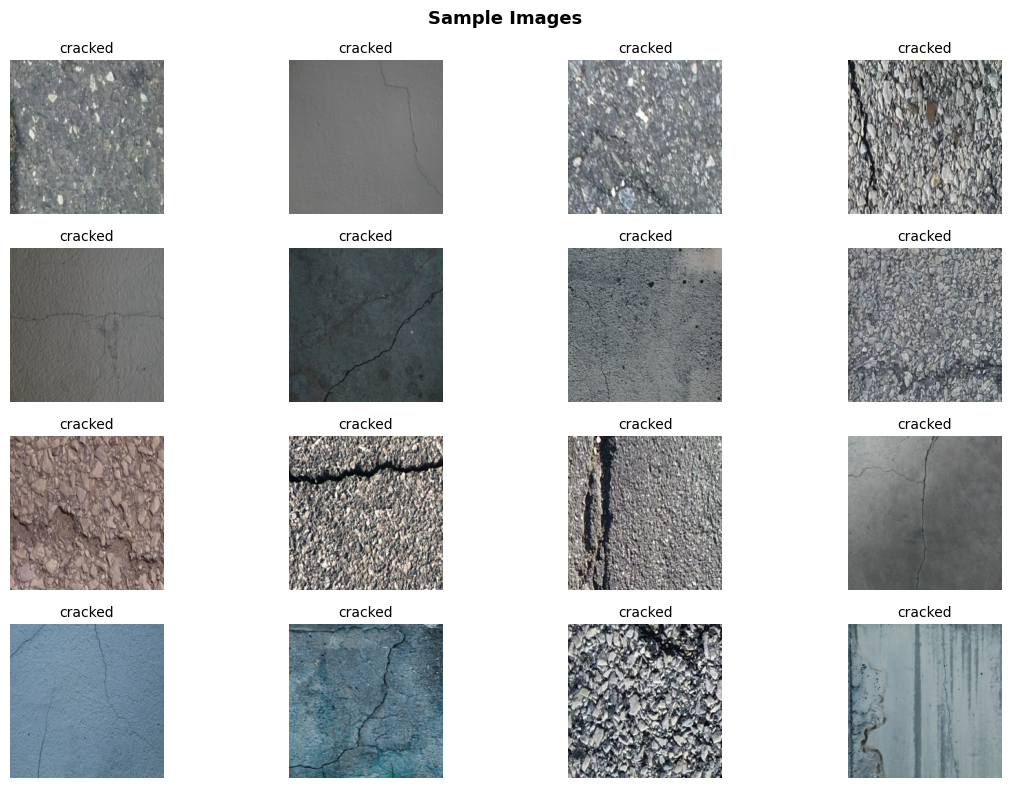

In [29]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(CLASS_NAMES[fixed_labels[i]], fontsize=10) 
    plt.axis('off')
plt.suptitle('Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Optimise the data pipeline.

In [30]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = (train_dataset.cache().shuffle(750).prefetch(buffer_size=AUTOTUNE))
valid_dataset = (valid_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))

 # Define the data augmentation pipeline.

In [31]:
# Augmentation for training only
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name= 'data_augumentation')

# Visualise augmentation effects on one image

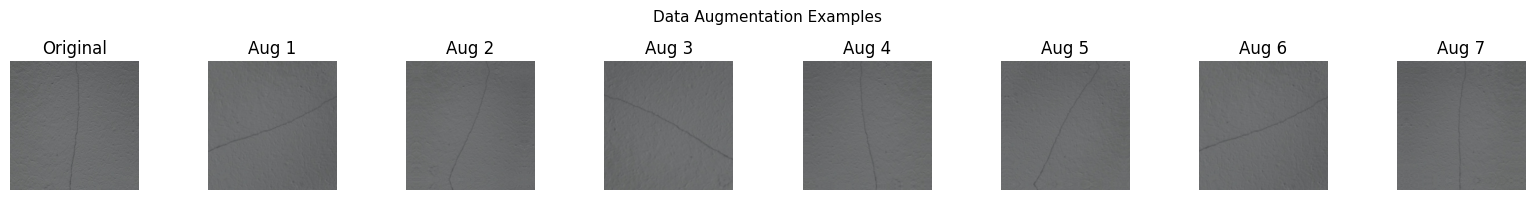

In [32]:
for images, _ in train_dataset.take(1):
    sample = images[0:1] # shape (1, 224, 224, 3)
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample,training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.show()

# Define shared callbacks and utilities.

In [33]:
os.makedirs('models', exist_ok=True)
def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [ tf.keras.callbacks.ModelCheckpoint(
        filepath=f'models/{name}_best.keras',
        monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=4, min_lr=1e-7, verbose=1
        ),
        ]
def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc= history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model',results_dir='./'):

    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # multiclass prediction (softmax -> argmax)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)
    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred,average="weighted"):.4f}')
    print(f'Recall: {recall_score(y_true, y_pred,average="weighted"):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted"):.4f}')

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names,digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='',xticklabels=class_names, yticklabels=class_names,
    annot_kws={'fontsize': 9, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return accuracy_score(y_true, y_pred)
print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


# Build the Custom CNN Architecture

In [34]:
INPUT_SHAPE = (IMG_SIZE[0],IMG_SIZE[1] , 3)
OUTPUTS = num_classes
def build_custom_cnn(input_shape, augmentation):
   
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
   
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    
    # Block 1: 32 filters
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Block 2: 64 filters
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Block 3: 128 filters
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name='custom_cnn')
    
cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augumentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

# Compile the custom CNN mdel.

In [35]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# Train the model and save the training history

In [36]:
cnn_history = cnn_model.fit(
    train_dataset, validation_data=valid_dataset,epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'), verbose=1)

Epoch 1/50


E0000 00:00:1785292257.429477      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/custom_cnn_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 227ms/step - accuracy: 0.9213 - loss: 0.2107 - val_accuracy: 0.8819 - val_loss: 0.4019 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.9376 - loss: 0.1838 - val_accuracy: 0.8819 - val_loss: 0.5144 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.9431 - loss: 0.1624 - val_accuracy: 0.9059 - val_loss: 0.3591 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 216ms/step - accuracy: 0.9469 - loss: 0.1617 - val_accuracy: 0.8953 - val_loss: 0.4427 - learning_rate: 0.0010
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.9477 - loss: 0.1525 - val_accuracy: 0.9420 - val_loss: 0.2195 - learning_rate: 0.0010
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 216ms/step - accuracy: 0.9486 - loss: 0.1597 - val_accuracy: 0.9273 - val_loss: 0.2754 - learning_rate: 0.0010
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 216ms/step - accuracy: 0.9487 - loss:

# Evaluate the Custom CNN on validation dataset

In [38]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(valid_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN -> val_loss: 0.0689
val_accuracy: 0.9773


# Visualise the Learning curves for the Custom CNN

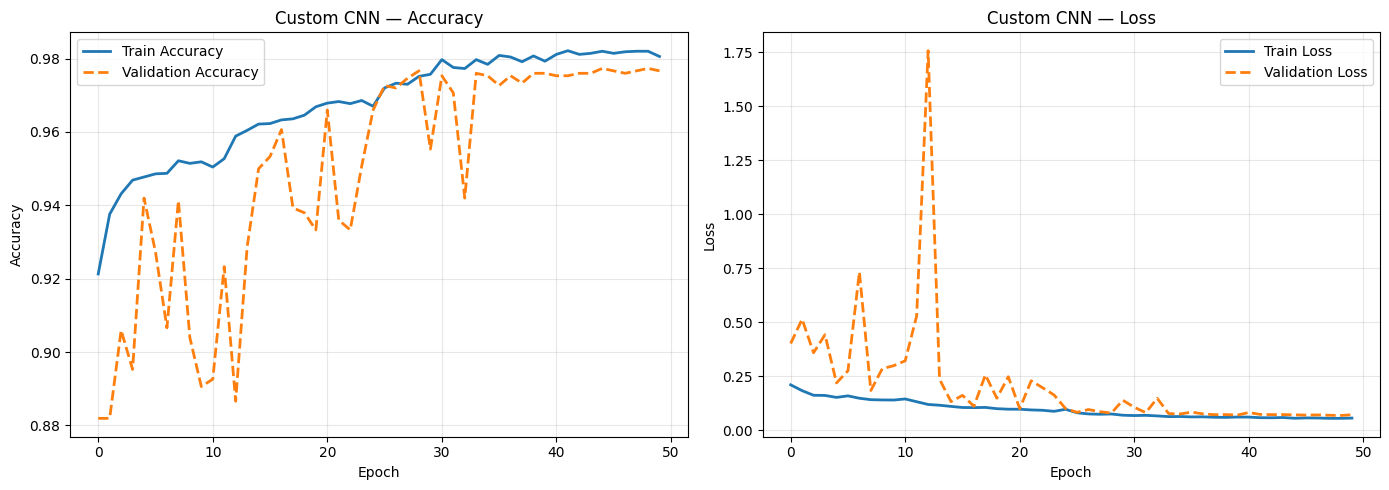

In [39]:
plot_learning_curves(cnn_history, 'Custom CNN')

# Evaluate the Custom CNN on test dataset

In [41]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_dataset, verbose=0)
print(f'Custom CNN -> test_loss: {cnn_val_loss:.4f}')
print(f'test_accuracy: {cnn_test_acc:.4f}')

Custom CNN -> test_loss: 0.0689
test_accuracy: 0.9647


# Visualise the Custom CNN using confusion matrix


Model
Accuracy : 0.9647
Precision : 0.9637
Recall: 0.9647
F1-Score : 0.9638

Classification Report:
              precision    recall  f1-score   support

     cracked     0.9732    0.9872    0.9801      1324
 not_cracked     0.8931    0.7978    0.8427       178

    accuracy                         0.9647      1502
   macro avg     0.9331    0.8925    0.9114      1502
weighted avg     0.9637    0.9647    0.9638      1502



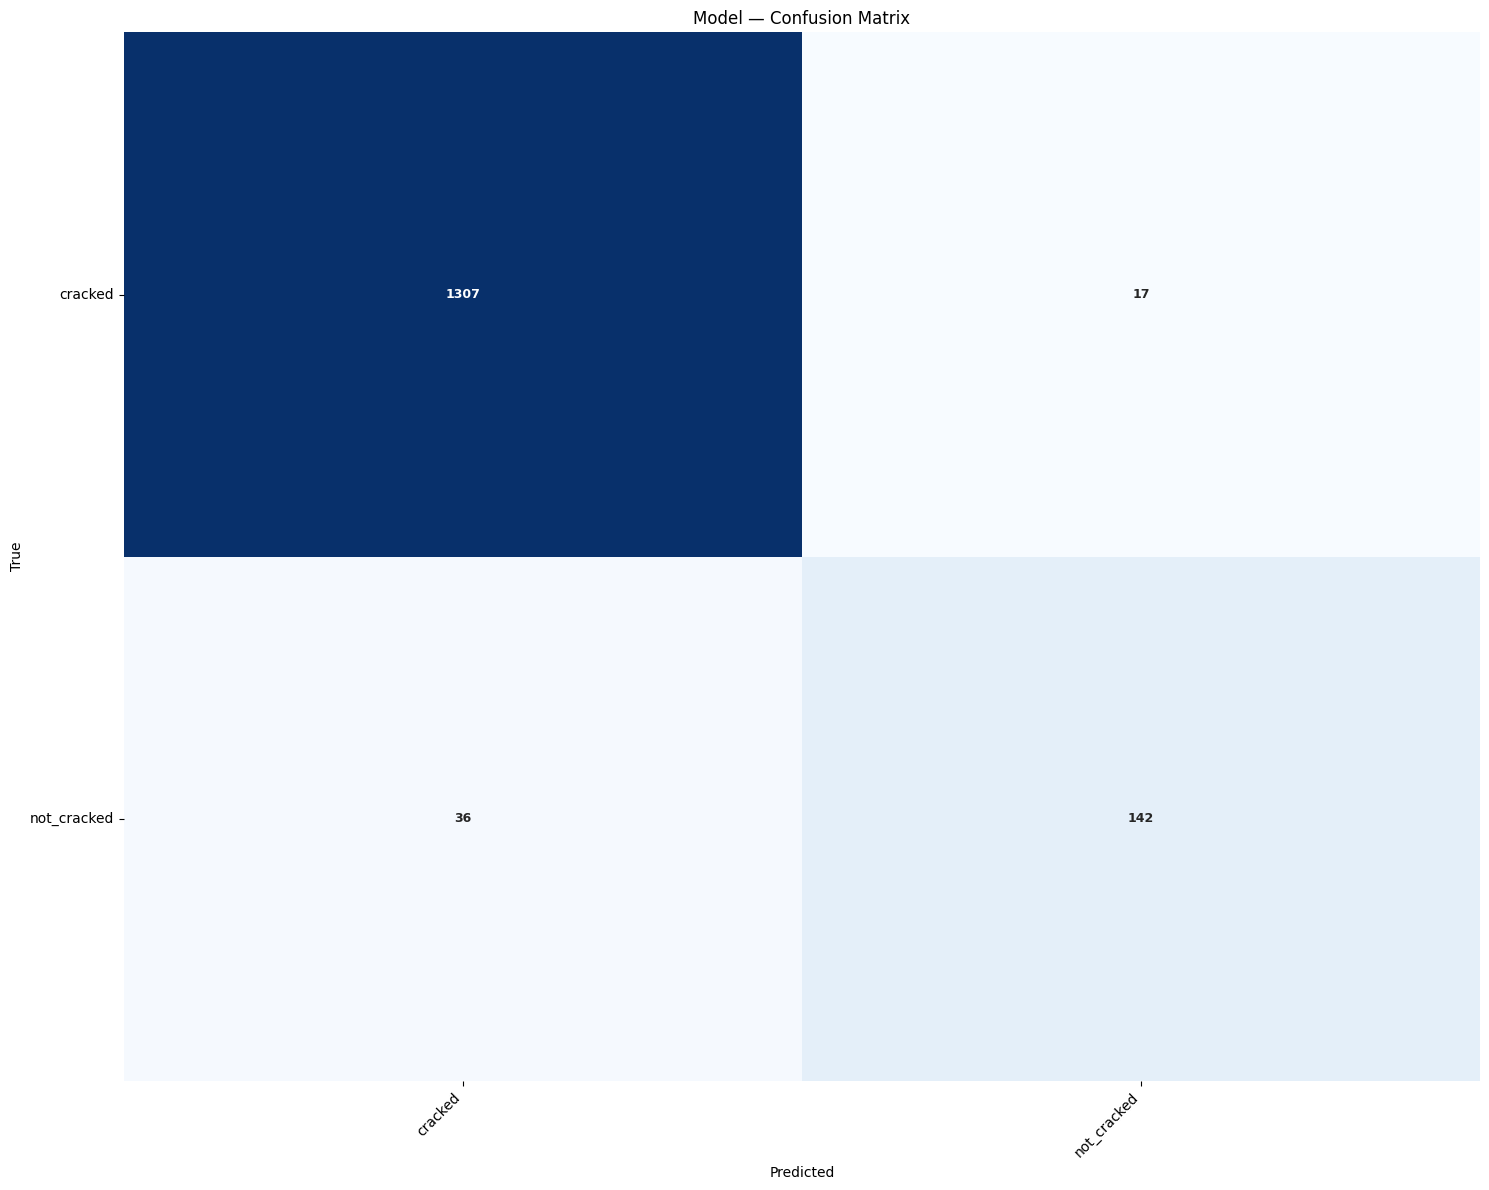

0.9647137150466045

In [44]:
evaluate_model(cnn_model, test_dataset, CLASS_NAMES)

# Predict on a new image.

In [54]:
def predict_image(img_path, models_dict, class_names, image_size=IMG_SIZE):
    
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) 
    
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()
    
    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        prob = mdl.predict(img_array, verbose=0)[0][0]
        label = class_names[int(prob <= 0.5)]
        print(f'{name:<25}: {label}')

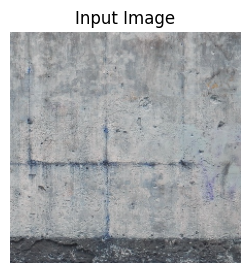


Predictions for: /kaggle/working/dataset/test/not_cracked/noncrack_noncrack_concrete_wall_14_21.jpg
----------------------------------------
Custom CNN               : not_cracked


In [55]:
image_path= '/kaggle/working/dataset/test/not_cracked/noncrack_noncrack_concrete_wall_14_21.jpg'
image_path = predict_image(
    image_path,
    {'Custom CNN': cnn_model},CLASS_NAMES
)

# Save Models 

In [57]:
os.makedirs('models', exist_ok=True)
cnn_model.save('models/custom_cnn.keras')

print('Models saved:')
print(' models/custom_cnn.keras')


Models saved:
 models/custom_cnn.keras
